In [24]:
from json import tool

from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.prebuilt import ToolNode, tools_condition
from langchain.tools import tool


from langchain_google_genai import GoogleGenerativeAIEmbeddings,ChatGoogleGenerativeAI
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS


from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, AIMessage

In [25]:
loader = PyPDFLoader("123.pdf")
docs = loader.load()

In [26]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [34]:
len(chunks)

3

In [27]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)
vector_store = FAISS.from_documents(chunks,embeddings)



In [28]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [29]:

load_dotenv()

llm = ChatGoogleGenerativeAI(
model="gemini-2.5-flash",
# temperature=0.2,
# max_tokens=100,   
# timeout=None,
# max_retries=2,
# other params...
)

# ******************** Tools*********************************
@tool
def calculator(first_num:float,second_num:float,operation:str)->float:
    """Performs basic arithmetic operations on two numbers."""
    try:
        if operation == 'add':
            return first_num + second_num
        elif operation == 'subtract':
            return first_num - second_num
        elif operation == 'multiply':
            return first_num * second_num
        elif operation == 'divide':
            if second_num != 0:
                return first_num / second_num
            else:
                return "Error: Division by zero is not allowed."
        else:
            return "Error: Invalid operation. Please choose from add, subtract, multiply, or divide."
    except Exception as e:
        return {"error":str(e)}
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        "query": query,
        "context": context,
        "metadata": metadata
    }
tools = [calculator,rag_tool]
tool_node = ToolNode(tools)

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

def chat_node(state:ChatState):
    messages= state['messages']
    response = llm.invoke(messages)
    return {'messages':[response]}

# db
conn = sqlite3.connect(database='chatbot.db', check_same_thread=False)
# Checkpointer
checkpointer = SqliteSaver(conn=conn)

graph = StateGraph(ChatState)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)

graph.add_edge(START,"chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools",'chat_node')
graph.add_edge("chat_node",END)

chatbot = graph.compile(checkpointer=checkpointer)

def retrieve_all_threads():
    all_threads = set()
    for checkpoint in checkpointer.list(None):
        all_threads.add(checkpoint.config['configurable']['thread_id'])

    return list(all_threads)
from langchain_core.messages import HumanMessage

# response = chatbot.invoke({"messages": [HumanMessage(content="what is 8 + 8?")]}, config={'configurable': {'thread_id': 'default_thread'}})
# print(response)

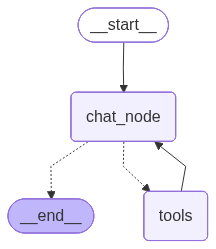

In [30]:
chatbot

In [31]:
CONFIG = {
    "configurable": {
        "thread_id": "st.session_state"
    }
}
response = chatbot.invoke(
        {"messages": [HumanMessage(content="use rag_tool to find the name of the person in the pdf")]},
        config=CONFIG
    )
ai_message = response["messages"][-1].content

In [32]:
ai_message

'I understand you\'re reiterating the request to use a `rag_tool` to find a name in a PDF.\n\nHowever, I need to clarify a fundamental limitation:\n\n**I do not have a `rag_tool` (or any other tool) that can directly access, open, or read a PDF file that is stored on your local computer, your network, or any private location.** My environment is separate from yours.\n\nThink of it this way: I am an AI language model, and I can only process information that you provide to me directly in our chat. I cannot "reach out" to your computer\'s file system.\n\n**To help you find the name, you *must* bring the content of the PDF to me.** Here\'s how:\n\n1.  **Copy and Paste the Text:** Open the PDF yourself, select the relevant text (or even the whole document if it\'s not too long), and paste it directly into our chat.\n2.  **Provide a Public Link:** If the PDF is hosted online and accessible to anyone via a web browser, provide me with the direct URL (web address) to that PDF. I might then be 

In [33]:

from langchain_google_genai import GoogleGenerativeAIEmbeddings,ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.prebuilt import ToolNode, tools_condition